In [21]:
%load_ext autoreload
%autoreload 2

In [41]:
import sys
import os

sys.path.insert(0, os.path.abspath("C:/Users/pc/Desktop/Week 5_6/fraud-detection/src/"))

In [44]:
from src.data_loader import load_data
from src.eda import *


print('Functions imported successfully!')
print()

Functions imported successfully!



### Load Fraud Dataset

In [3]:
data = load_data('C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/raw/Fraud_Data.csv')
data.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## Data Analysis and Preprocessing

### # Data Cleaning

In [4]:
# Handle missing values
df_clean = handle_missing_values(data, missing_threshold=0.5)


Missing values after treatment:
0


In [5]:
# Remove duplicates
df_clean = remove_duplicates(df_clean)

Number of duplicate rows: 0
Shape after removing duplicates: (151112, 11)


In [6]:
# To automatically correct data types
df_clean = auto_correct_data_types(df_clean)

Updated Data Types:
user_id             Int64
signup_time        string
purchase_time      string
purchase_value      Int64
device_id          string
source             string
browser            string
sex                string
age                 Int64
ip_address        Float64
class               Int64
dtype: object


In [7]:
numeric_cols = df_clean.select_dtypes(include=['number']).columns.tolist()

print("Numeric columns:", numeric_cols)

Numeric columns: ['user_id', 'purchase_value', 'age', 'ip_address', 'class']



Variable: user_id
count         151112.0
mean      200171.04097
std      115369.285024
min                2.0
25%           100642.5
50%           199958.0
75%           300054.0
max           400000.0
Name: user_id, dtype: Float64


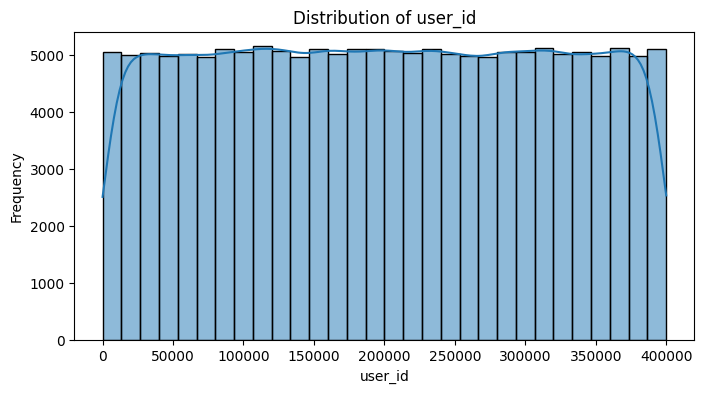


Variable: purchase_value
count     151112.0
mean     36.935372
std      18.322762
min            9.0
25%           22.0
50%           35.0
75%           49.0
max          154.0
Name: purchase_value, dtype: Float64


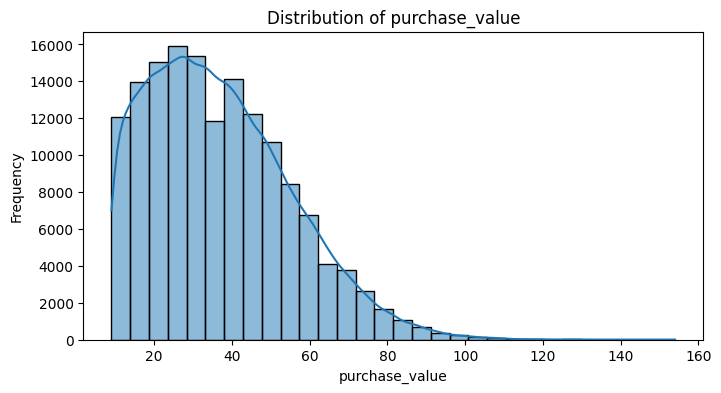


Variable: age
count     151112.0
mean     33.140704
std       8.617733
min           18.0
25%           27.0
50%           33.0
75%           39.0
max           76.0
Name: age, dtype: Float64


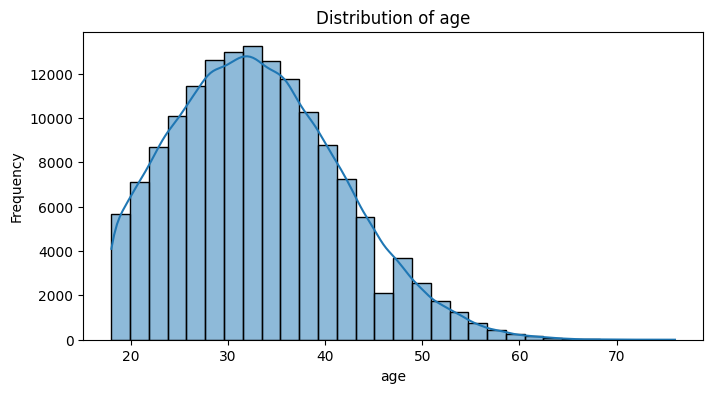


Variable: ip_address
count             151112.0
mean     2152145330.958826
std      1248497030.100426
min           52093.496895
25%       1085933882.53156
50%       2154770162.40662
75%      3243257679.722522
max       4294850499.67884
Name: ip_address, dtype: Float64


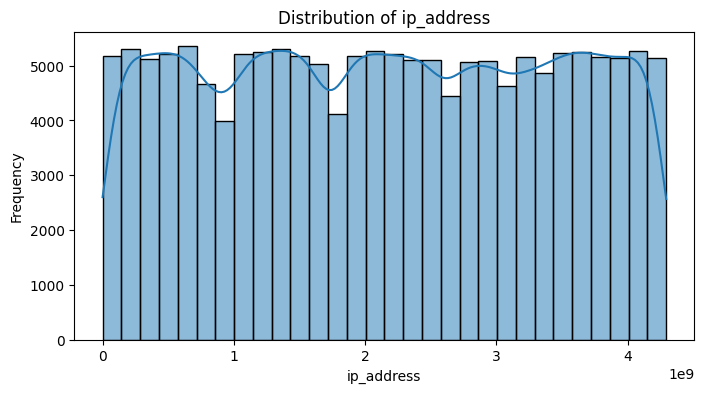


Variable: class
count    151112.0
mean     0.093646
std      0.291336
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: class, dtype: Float64


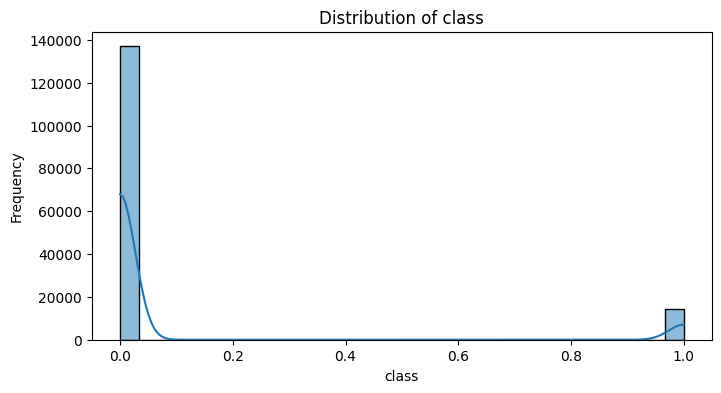

In [38]:
univariate_analysis(df_clean, numeric_cols)


user_id vs class
Correlation: 0.0019


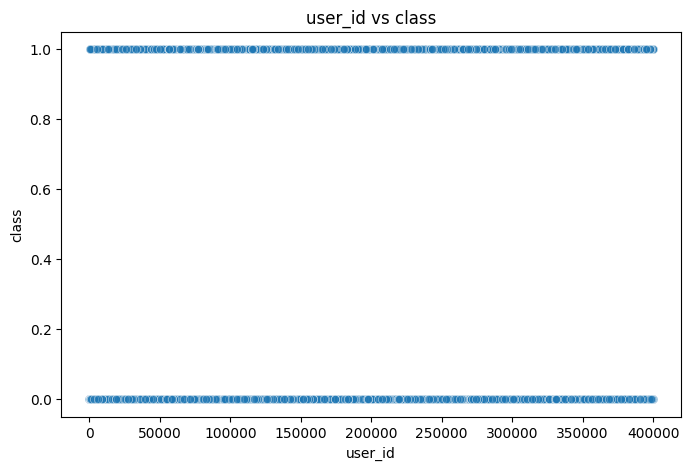


signup_time vs class
Average Target by Category:
signup_time
2015-08-18 04:31:11    1.0
2015-08-18 03:25:36    1.0
2015-01-01 00:12:19    1.0
2015-01-01 00:12:18    1.0
2015-01-01 00:12:17    1.0
                      ... 
2015-08-18 03:52:09    0.0
2015-01-01 00:12:09    0.0
2015-01-01 00:09:55    0.0
2015-01-01 00:08:56    0.0
2015-01-01 00:07:11    0.0
Name: class, Length: 151112, dtype: Float64


: 

In [ ]:
bivariate_analysis(df_clean, target="class")


Class Distribution for 'class'
----------------------------------------
        Count  Percentage (%)
class                        
0      136961           90.64
1       14151            9.36

Imbalance Ratio: 9.68:1


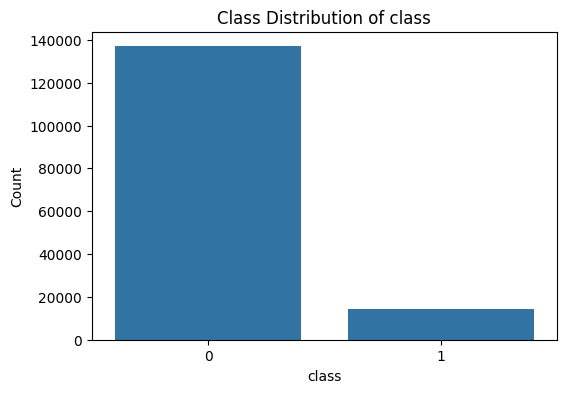

        Count  Percentage (%)
class                        
0      136961           90.64
1       14151            9.36


In [8]:
claim_distribution = quantify_class_imbalance(
    df_clean,
    target="class"
)

print(claim_distribution)

### # Geolocation Integration

In [9]:
# Convert IP addresses to integer format
df1 = convert_ip_to_integer(df_clean, "ip_address")

Converted 'ip_address' to 'ip_address_int'


In [10]:
# To Save the processed data to a new csv file
output_file_path = "C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/processed/Fraud_Data_cleaned.csv"
df1.to_csv(output_file_path, index=False)

In [11]:
# Merge Fraud_Data.csv with IpAddress_to_Country.csv using range-based lookup. 
fraud_df = pd.read_csv('C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/processed/Fraud_Data_cleaned.csv')
ip_country_df = pd.read_csv('C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/raw/IpAddress_to_Country.csv')

# Merge datasets
fraud_country_df = merge_fraud_with_country(fraud_df,ip_country_df)

# Inspect result
print(fraud_country_df.head())

Original fraud records : 151,112
Matched records        : 129,146
Match rate             : 85.46%
     user_id          signup_time        purchase_time  purchase_value  \
634   247547  2015-06-28 03:00:34  2015-08-09 03:57:29              47   
635   220737  2015-01-28 14:21:11  2015-02-11 20:28:28              15   
636   390400  2015-03-19 20:49:09  2015-04-11 23:41:23              44   
637    69592  2015-02-24 06:11:57  2015-05-23 16:40:14              55   
638   174987  2015-07-07 12:58:11  2015-11-03 04:04:30              51   

         device_id  source browser sex  age    ip_address  class  \
634  KIXYSVCHIPQBR     SEO  Safari   F   30  1.677886e+07      0   
635  PKYOWQKWGJNJI     SEO  Chrome   F   34  1.684205e+07      0   
636  LVCSXLISZHVUO     Ads      IE   M   29  1.684366e+07      0   
637  UHAUHNXXUADJE  Direct  Chrome   F   30  1.693873e+07      0   
638  XPGPMOHIDRMGE     SEO  Chrome   F   37  1.697198e+07      0   

     ip_address_int  lower_bound_ip_address  upp

#### -	Analyze fraud patterns by country.

In [12]:
# country level fraud summary
country_summary(fraud_country_df)

,count,count
0,United States,58049
1,China,12038
2,Japan,7306
3,United Kingdom,4490
4,Korea Republic of,4162
5,Germany,3646
6,France,3161
7,Canada,2975
8,Brazil,2961
9,Italy,1944



Top Countries by Fraud Rate
                   country  Total_Transactions  Fraud_Transactions  \
166           Turkmenistan                   1                   1   
115                Namibia                  23                  10   
154              Sri Lanka                  31                  13   
98              Luxembourg                  72                  28   
177  Virgin Islands (U.S.)                   3                   1   
51                 Ecuador                 106                  28   
164                Tunisia                 118                  31   
131                   Peru                 119                  31   
20                 Bolivia                  53                  13   
89                  Kuwait                  90                  21   
80                 Ireland                 240                  55   
120            New Zealand                 278                  62   
173             Uzbekistan                  10               

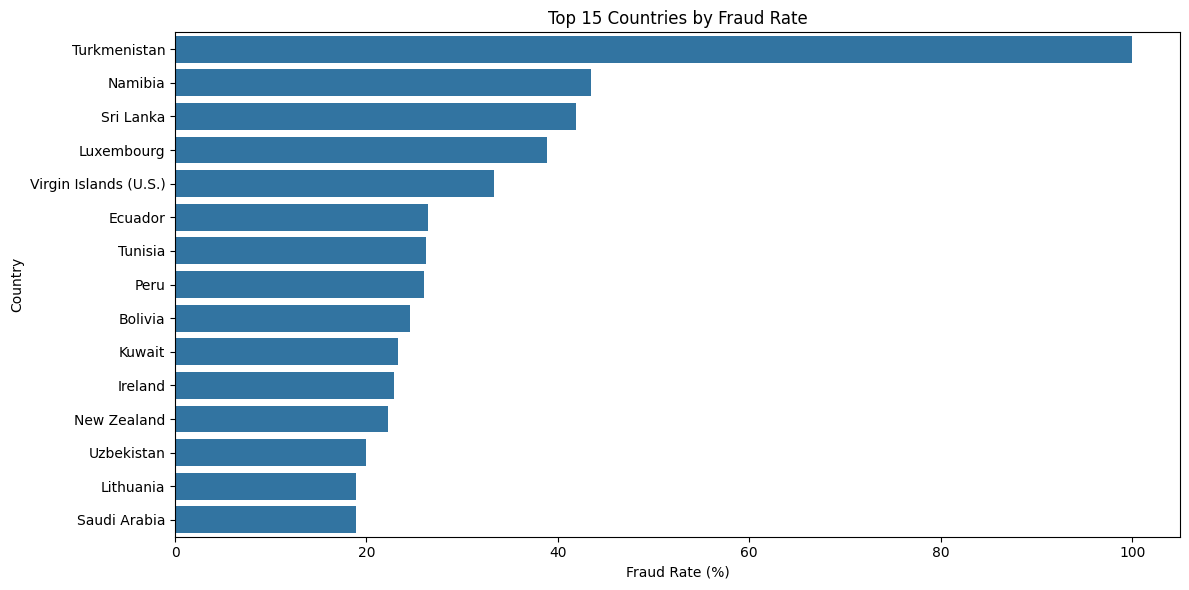

,country,Total_Transactions,Fraud_Transactions,Fraud_Rate (%)
166,Turkmenistan,1,1,100.00
115,Namibia,23,10,43.48
154,Sri Lanka,31,13,41.94
98,Luxembourg,72,28,38.89
177,Virgin Islands (U.S.),3,1,33.33


In [13]:
country_fraud_summary = analyze_fraud_by_country(
    fraud_country_df,
    country_col="country",
    fraud_col="class"
)

country_fraud_summary.head()

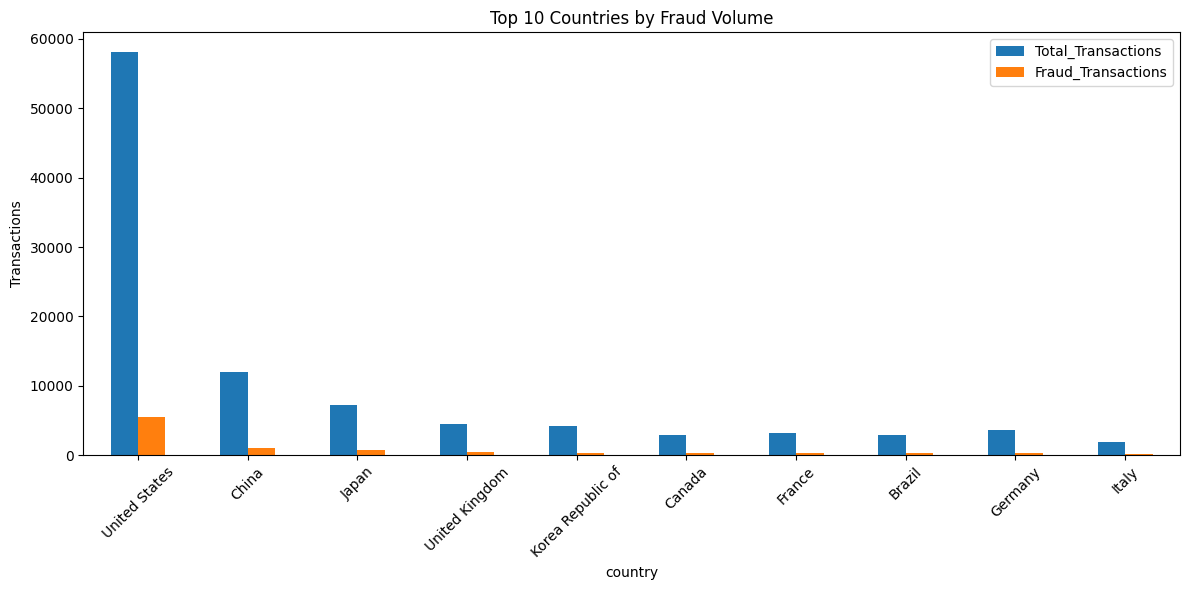

,country,Total_Transactions,Fraud_Transactions
0,United States,58049,5551
1,China,12038,1043
2,Japan,7306,715
3,United Kingdom,4490,477
4,Korea Republic of,4162,380
5,Canada,2975,348
6,France,3161,300
7,Brazil,2961,270
8,Germany,3646,262
9,Italy,1944,166


In [14]:
plot_country_fraud_volume(
    fraud_country_df,
    country_col="country",
    fraud_col="class"
)

In [15]:
high_risk_countries = identify_high_risk_countries(
    fraud_country_df,
    min_transactions=100
)

print(high_risk_countries.head(10))

                  country  Total_Transactions  Fraud_Transactions  \
51                Ecuador                 106                  28   
164               Tunisia                 118                  31   
131                  Peru                 119                  31   
80                Ireland                 240                  55   
120           New Zealand                 278                  62   
144          Saudi Arabia                 264                  50   
47                Denmark                 490                  78   
35                  Chile                 417                  64   
67                 Greece                 231                  33   
169  United Arab Emirates                 114                  16   

     Fraud_Rate (%)  
51        26.415094  
164       26.271186  
131       26.050420  
80        22.916667  
120       22.302158  
144       18.939394  
47        15.918367  
35        15.347722  
67        14.285714  
169       14.035088 

In [16]:
fraud_df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'ip_address_int'],
      dtype='str')

In [13]:
fraud_df.head(10)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_address_int
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,NaN
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,NaN
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,NaN
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,NaN
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,NaN
5,159135,2015-05-21 06:03:03,2015-07-09 08:05:14,42,ALEYXFXINSXLZ,Ads,Chrome,M,18,2.809315e+09,0,NaN
6,50116,2015-08-01 22:40:52,2015-08-27 03:37:57,11,IWKVZHJOCLPUR,Ads,Chrome,F,19,3.987484e+09,0,NaN
7,360585,2015-04-06 07:35:45,2015-05-25 17:21:14,27,HPUCUYLMJBYFW,Ads,Opera,M,34,1.692459e+09,0,NaN
8,159045,2015-04-21 23:38:34,2015-06-02 14:01:54,30,ILXYDOZIHOOHT,SEO,IE,F,43,3.719094e+09,0,NaN
9,182338,2015-01-25 17:49:49,2015-03-23 23:05:42,62,NRFFPPHZYFUVC,Ads,IE,M,31,3.416747e+08,0,NaN


### # Feature Engineering 

In [17]:
fraud_df.columns = fraud_df.columns.str.strip()

In [18]:
df_features = create_frequency_velocity_features(
    fraud_df,
    user_col="user_id",
    time_col="purchase_time",
    amount_col="purchase_value",
    windows=("1D", "7D", "30D")
)

print(df_features.head())

   user_id          signup_time       purchase_time  purchase_value  \
0        2  2015-01-11 03:47:13 2015-02-21 10:03:37              54   
1        4  2015-06-02 16:40:57 2015-09-26 21:32:16              41   
2        8  2015-05-28 07:53:06 2015-08-13 11:53:07              47   
3        9  2015-05-16 15:58:32 2015-05-20 23:06:42              62   
4       12  2015-01-10 06:25:12 2015-03-04 20:56:37              35   

       device_id  source  browser sex  age    ip_address  class  \
0  FGBQNDNBETFJJ     SEO   Chrome   F   25  8.802175e+08      0   
1  MKFUIVOHLJBYN  Direct   Safari   F   38  2.785906e+09      0   
2  SCQGQALXBUQZJ     SEO   Chrome   M   25  3.560567e+08      0   
3  IEZOHXPZBIRTE     SEO  FireFox   M   21  7.591047e+08      0   
4  MSNWCFEHKTIOY     Ads   Safari   M   19  2.985180e+09      0   

   ip_address_int  txn_count_1D  txn_velocity_1D  txn_count_7D  \
0             NaN           1.0             54.0           1.0   
1             NaN           1.0       

In [27]:
df_features2 = create_time_features(df_features, time_col="purchase_time")

print(df_features2)

        user_id          signup_time       purchase_time  purchase_value  \
0             2  2015-01-11 03:47:13 2015-02-21 10:03:37              54   
1             4  2015-06-02 16:40:57 2015-09-26 21:32:16              41   
2             8  2015-05-28 07:53:06 2015-08-13 11:53:07              47   
3             9  2015-05-16 15:58:32 2015-05-20 23:06:42              62   
4            12  2015-01-10 06:25:12 2015-03-04 20:56:37              35   
...         ...                  ...                 ...             ...   
151107   399992  2015-06-04 17:43:28 2015-09-30 07:19:17              82   
151108   399993  2015-07-30 03:41:08 2015-10-01 07:16:25              20   
151109   399995  2015-03-10 05:19:31 2015-06-05 23:36:56              33   
151110   399997  2015-06-30 09:02:16 2015-10-07 20:56:54              66   
151111   400000  2015-03-16 23:03:56 2015-04-20 06:27:52              58   

            device_id  source  browser sex  age    ip_address  class  \
0       FGBQNDN

In [28]:
df_features2 = create_time_since_signup_feature(df_features2, unit="hours")

print(df_features2)

        user_id         signup_time       purchase_time  purchase_value  \
0             2 2015-01-11 03:47:13 2015-02-21 10:03:37              54   
1             4 2015-06-02 16:40:57 2015-09-26 21:32:16              41   
2             8 2015-05-28 07:53:06 2015-08-13 11:53:07              47   
3             9 2015-05-16 15:58:32 2015-05-20 23:06:42              62   
4            12 2015-01-10 06:25:12 2015-03-04 20:56:37              35   
...         ...                 ...                 ...             ...   
151107   399992 2015-06-04 17:43:28 2015-09-30 07:19:17              82   
151108   399993 2015-07-30 03:41:08 2015-10-01 07:16:25              20   
151109   399995 2015-03-10 05:19:31 2015-06-05 23:36:56              33   
151110   399997 2015-06-30 09:02:16 2015-10-07 20:56:54              66   
151111   400000 2015-03-16 23:03:56 2015-04-20 06:27:52              58   

            device_id  source  browser sex  age    ip_address  ...  \
0       FGBQNDNBETFJJ     SEO

### # Data Transformation

In [29]:
numeric_cols = df_features2.select_dtypes(include=['number']).columns.tolist()

print("Numeric columns:", numeric_cols)

Numeric columns: ['user_id', 'purchase_value', 'age', 'ip_address', 'class', 'ip_address_int', 'txn_count_1D', 'txn_velocity_1D', 'txn_count_7D', 'txn_velocity_7D', 'txn_count_30D', 'txn_velocity_30D', 'hour_of_day', 'day_of_week', 'time_since_signup']


In [ ]:
df_features2.set_index("user_id", inplace=True)

In [32]:
numeric_cols = [col for col in numeric_cols if col != "user_id"]

In [49]:
# Standardize numerical features
df_scaled, scaler = scale_numerical_features(
    df_features2,
    columns=numeric_cols,
    method="standard"
)

c:\Users\pc\Desktop\week 5_6\fraud-detection\venv\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\pc\Desktop\week 5_6\fraud-detection\venv\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\pc\Desktop\week 5_6\fraud-detection\venv\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Scaled columns using standard scaler:
['purchase_value', 'age', 'ip_address', 'class', 'ip_address_int', 'txn_count_1D', 'txn_velocity_1D', 'txn_count_7D', 'txn_velocity_7D', 'txn_count_30D', 'txn_velocity_30D', 'hour_of_day', 'day_of_week', 'time_since_signup']


In [ ]:
df_features2.set_index("user_id", inplace=True)

In [ ]:
categorical_cols = df_features2.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)

Categorical columns: ['device_id', 'source', 'browser', 'sex']


C:\Users\pc\AppData\Local\Temp\ipykernel_4744\633901568.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_features2.select_dtypes(include=["object", "category"]).columns.tolist()


In [ ]:
# one hot encode categorical features
df_encoded = one_hot_encode_features(
    df_features2,
    columns=["source", "browser", "sex"],
    drop_first=True
)

Encoding columns: ['source', 'browser', 'sex']


### # Handle Class Imbalance

In [39]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [45]:
X_train_balanced, y_train_balanced = apply_smote_to_training_set(
    X_train,
    y_train
)

c:\Users\pc\Desktop\week 5_6\fraud-detection\venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['ip_address_int']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Original class distribution:
class
0    109568
1     11321
Name: count, dtype: int64

Resampled class distribution:
class
0    109568
1    109568
Name: count, dtype: int64


In [48]:
# To Save the processed data to a new csv file
output_file_path = "C:/Users/pc/Desktop/Week 5_6/fraud-detection/data/processed/Fraud_Data_processed.csv"
df_encoded.to_csv(output_file_path, index=False)